In [3]:
%pip install plotly 

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from plotly import express as px
from plotly import graph_objects as go
from plotly.subplots import make_subplots
pd.set_option('display.max_columns', None)

In [5]:
df = pd.read_csv("../Data/processed/processed.csv")

In [6]:
df.head()

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi,pulse_pressure,hypertension,overweight
0,2,168,62.0,110,80,1,1,0,0,1,0,50.4,22.0,30,0,0
1,1,156,85.0,140,90,3,1,0,0,1,1,55.4,34.9,50,1,1
2,1,165,64.0,130,70,3,1,0,0,0,1,51.6,23.5,60,0,0
3,2,169,82.0,150,100,1,1,0,0,1,1,48.2,28.7,50,1,1
4,1,156,56.0,100,60,1,1,0,0,0,0,47.8,23.0,40,0,0


In [7]:
df.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
gender,68743.0,1.348719,0.476568,1.0,1.0,1.0,2.0,2.0
height,68743.0,164.396288,7.985485,100.0,159.0,165.0,170.0,250.0
weight,68743.0,74.123531,14.306606,30.0,65.0,72.0,82.0,200.0
ap_hi,68743.0,126.616688,16.764122,60.0,120.0,120.0,140.0,240.0
ap_lo,68743.0,81.382584,9.676878,40.0,80.0,80.0,90.0,190.0
cholesterol,68743.0,1.364823,0.679051,1.0,1.0,1.0,2.0,3.0
gluc,68743.0,1.226088,0.572062,1.0,1.0,1.0,1.0,3.0
smoke,68743.0,0.087994,0.283289,0.0,0.0,0.0,0.0,1.0
alco,68743.0,0.053635,0.225297,0.0,0.0,0.0,0.0,1.0
active,68743.0,0.803384,0.397443,0.0,1.0,1.0,1.0,1.0


In [8]:
# Conteo y porcentaje
conteo = df['cardio'].value_counts()
pct    = df['cardio'].value_counts(normalize=True) * 100

resumen = pd.DataFrame({'pacientes': conteo, 'porcentaje (%)': pct.round(1)})
resumen.index = ['Sin enfermedad (0)', 'Con enfermedad (1)']
print(resumen)

                    pacientes  porcentaje (%)
Sin enfermedad (0)      34720            50.5
Con enfermedad (1)      34023            49.5


In [10]:
import os
os.makedirs('../img', exist_ok=True)
print("✓ Carpeta img/ creada")

✓ Carpeta img/ creada


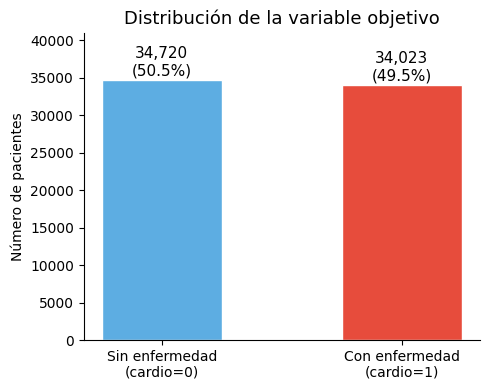

In [11]:
# Gráfico
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['Sin enfermedad\n(cardio=0)', 'Con enfermedad\n(cardio=1)'],
              conteo.values,
              color=['#5DADE2', '#E74C3C'], edgecolor='white', width=0.5)

for bar, val, p in zip(bars, conteo.values, pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}\n({p:.1f}%)', ha='center', va='bottom', fontsize=11)

ax.set_title('Distribución de la variable objetivo', fontsize=13)
ax.set_ylabel('Número de pacientes')
ax.set_ylim(0, conteo.max() * 1.18)
sns.despine()
plt.tight_layout()
plt.savefig('../img/01_target_balance.png', bbox_inches='tight')
plt.show()

/var/folders/nb/37g3qycx0rq_njs_r08md0lm0000gn/T/ipykernel_7863/2008917905.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='cardio', y=col, ax=ax,
/var/folders/nb/37g3qycx0rq_njs_r08md0lm0000gn/T/ipykernel_7863/2008917905.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Sin enfermedad', 'Con enfermedad'])
/var/folders/nb/37g3qycx0rq_njs_r08md0lm0000gn/T/ipykernel_7863/2008917905.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='cardio', y=col, ax=ax,
/var/folders/nb/37g3qycx0rq_njs_r08md0lm0000gn/T/ipykernel_7863/2008917905.py:15: UserWarning: set_

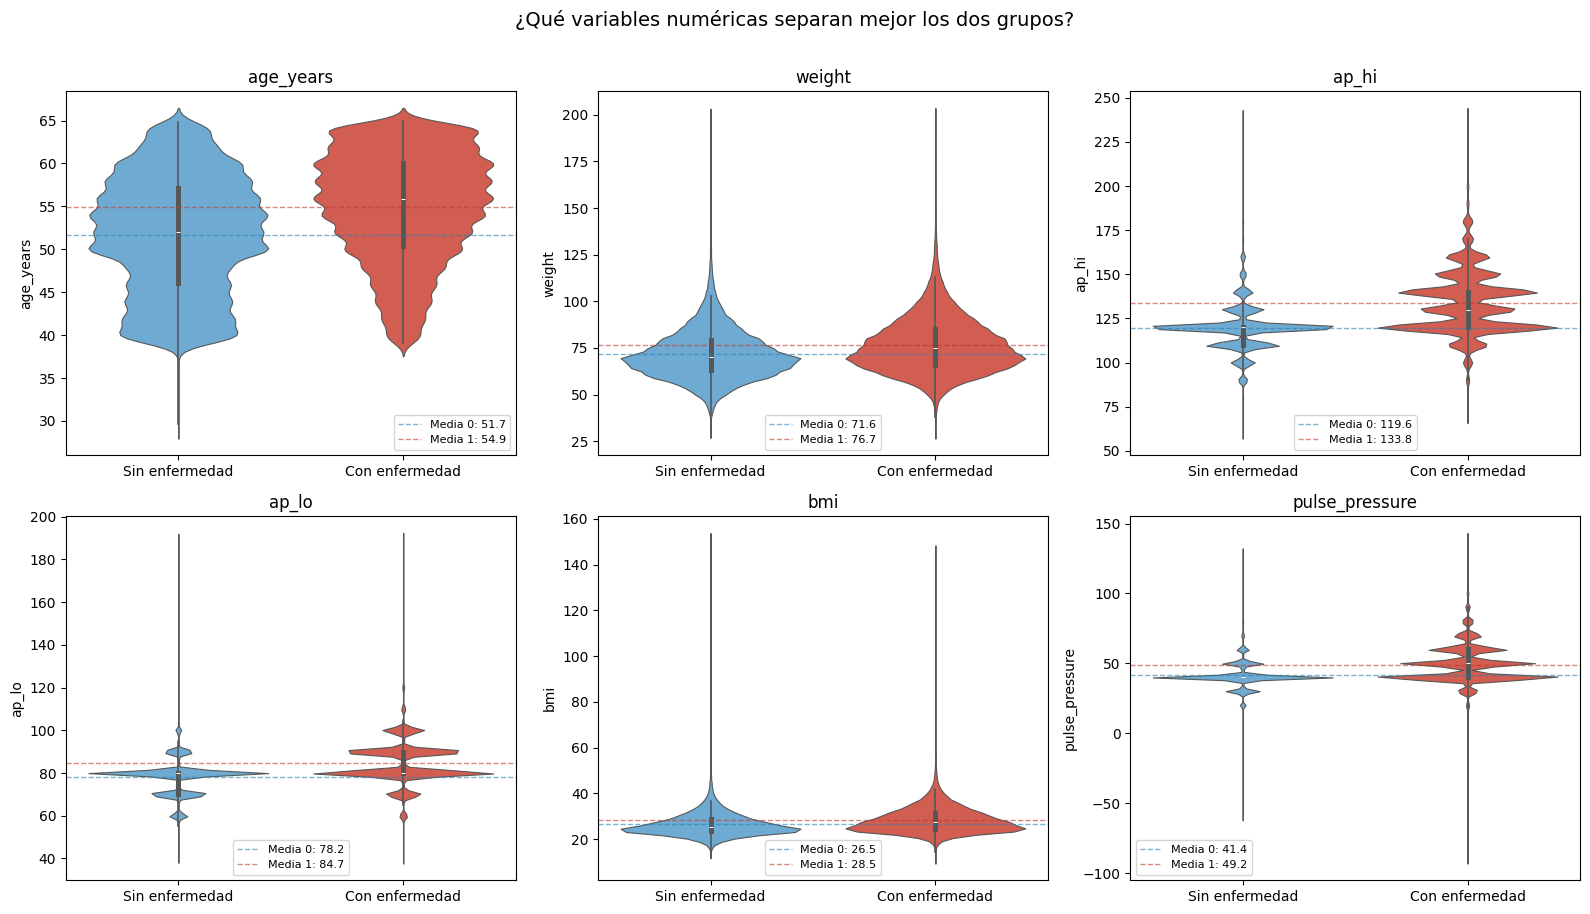

In [14]:
cols_violin = ['age_years', 'weight', 'ap_hi', 'ap_lo', 'bmi', 'pulse_pressure']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, col in zip(axes.flatten(), cols_violin):
    sns.violinplot(data=df, x='cardio', y=col, ax=ax,
                   palette=['#5DADE2', '#E74C3C'],   # ← lista en vez de diccionario
                   inner='box', linewidth=0.8)

    m0 = df[df['cardio'] == df['cardio'].unique()[0]][col].mean()
    m1 = df[df['cardio'] == df['cardio'].unique()[1]][col].mean()
    ax.axhline(m0, color='#2980B9', linewidth=1, linestyle='--', alpha=0.6, label=f'Media 0: {m0:.1f}')
    ax.axhline(m1, color='#C0392B', linewidth=1, linestyle='--', alpha=0.6, label=f'Media 1: {m1:.1f}')

    ax.set_xticklabels(['Sin enfermedad', 'Con enfermedad'])
    ax.set_title(col, fontsize=12)
    ax.set_xlabel('')
    ax.legend(fontsize=8)

plt.suptitle('¿Qué variables numéricas separan mejor los dos grupos?', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../img/s2a_violinplots.png', bbox_inches='tight')
plt.show()